## Reproducibility Notes

**Random Seed**: Set to `42` for consistent results across runs

**Simulation Parameters**: 
- **Days**: 730 (2 years)
- **Players**: ~1,600 total across all categories
  - 300 players per core strategy (1,500 random + 100 fixed)
  
**Sample Size per Strategy**: ~219,000 data points per core strategy (300 players × 730 days)

These changes ensure:
1. **Consistent results** - Same seed produces identical outcomes
2. **Very narrow confidence intervals** - Large sample size reduces statistical variance
3. **Reliable strategy comparison** - Clear winners and losers with minimal overlap

# Powerup Simulation Analysis

This notebook runs the simulation logic defined in `simulate_powerups.py` and visualizes the results with 95% Confidence Intervals.

## Setup

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add current directory to path to import script
sys.path.append(os.getcwd())

from simulate_powerups import (
    run_simulation,
    ProceduralStrategy,
    BenchmarkStrategy,
    AdaptiveStrategy,
)

# Set Plot Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
def get_rank_palette(df, cat_col, val_col="Score Ratio"):
    """
    Returns a palette dictionary where:
    1st (highest mean) -> Gold
    2nd -> Silver
    3rd -> Bronze
    Others -> Blue/Gray
    """
    # Calculate means to determine rank
    means = df.groupby(cat_col)[val_col].mean().sort_values(ascending=False)
    ranks = means.index.tolist()

    palette = {}
    # Gold, Silver, Bronze
    medal_colors = {0: "#FFD700", 1: "#C0C0C0", 2: "#CD7F32"}
    default_color = "#5975A4"  # Muted Blue

    for i, cat in enumerate(ranks):
        palette[cat] = medal_colors.get(i, default_color)

    return palette


def add_bar_labels(ax, fmt="%.3f"):
    """Adds labels inside the bars in a bar plot."""
    # Annotate each bar container
    for container in ax.containers:
        # Use negative padding to place inside the bar
        # Depending on bar lightness, color might need adjustment, but black is usually safe for these colors
        ax.bar_label(container, fmt=fmt, label_type="edge", padding=-50)

## Simulate

In [3]:
# Run the Simulation
import random
import numpy as np

# Set Random Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Running Simulation... (This may take a moment)")
players, strategies = run_simulation(return_data=True, seed=SEED)
print(f"Simulation Complete. Processed {len(players)} players.")

Running Simulation... (This may take a moment)
Starting simulation for 730 days...
Simulation Complete. Processed 1581 players.


In [4]:
# Build DataFrame
data = []

# Calculate Benchmark Mean for Ratio
benchmark_scores = [
    p.score for pid, p in players.items() if strategies[pid].name == "Benchmark"
]
benchmark_mean = (
    sum(benchmark_scores) / len(benchmark_scores) if benchmark_scores else 1
)

for pid, p in players.items():
    strat = strategies[pid]

    row = {
        "Name": p.name,
        "Score": p.score,
        "Score Ratio": p.score / benchmark_mean,
        "Streak": p.answer_streak,
        "Strategy Type": strat.name,
    }

    # Extract Dimensions
    if isinstance(strat, ProceduralStrategy):
        row["Core Strategy"] = strat.core_strategy
        row["Speed"] = strat.speed
        row["Correctness"] = strat.correctness
        row["Aggression"] = strat.aggression
    elif isinstance(strat, BenchmarkStrategy):
        row["Core Strategy"] = "Benchmark"
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"
    else:
        # Fallback
        row["Core Strategy"] = strat.name
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"

    data.append(row)

df = pd.DataFrame(data)
df.head()

,Name,Score,Score Ratio,Streak,Strategy Type,Core Strategy,Speed,Correctness,Aggression
0,Benchmark_1,103905,1.020452,670,Benchmark,Benchmark,N/A,N/A,N/A
1,Benchmark_2,102230,1.004002,659,Benchmark,Benchmark,N/A,N/A,N/A
2,Benchmark_3,102305,1.004739,660,Benchmark,Benchmark,N/A,N/A,N/A
3,Benchmark_4,103235,1.013872,666,Benchmark,Benchmark,N/A,N/A,N/A
4,Benchmark_5,99420,0.976405,641,Benchmark,Benchmark,N/A,N/A,N/A


## Results

### By strategy

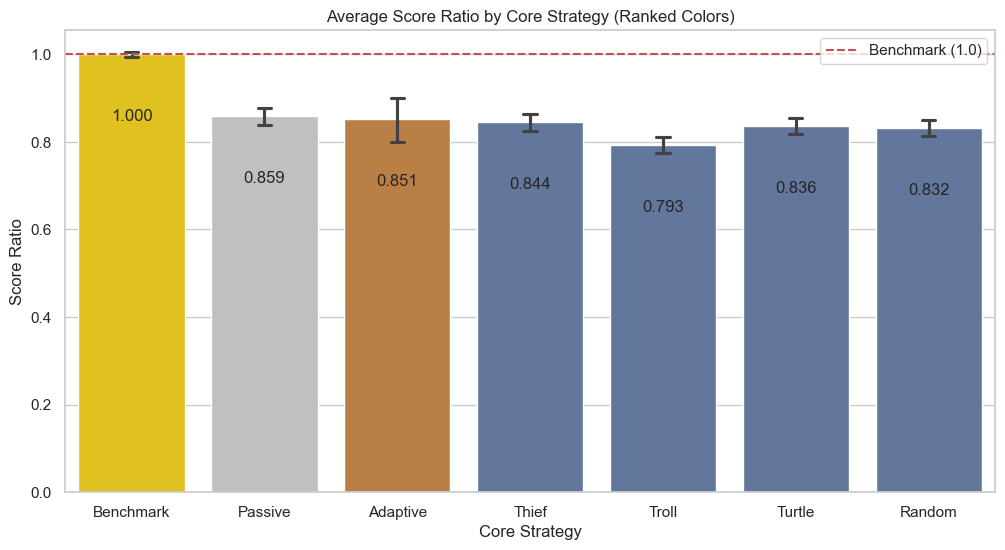

In [5]:
# Core Strategy Performance
plt.figure(figsize=(12, 6))

# Define palette based on rank (Gold, Silver, Bronze...)
palette = get_rank_palette(df, "Core Strategy", "Score Ratio")

# Using Score Ratio with modern seaborn API
ax = sns.barplot(
    data=df,
    x="Core Strategy",
    y="Score Ratio",
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Core Strategy",
    palette=palette,
    legend=False,
)

# Add Labels
add_bar_labels(ax, fmt="%.3f")

plt.title("Average Score Ratio by Core Strategy (Ranked Colors)")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark (1.0)")
plt.legend()
plt.show()

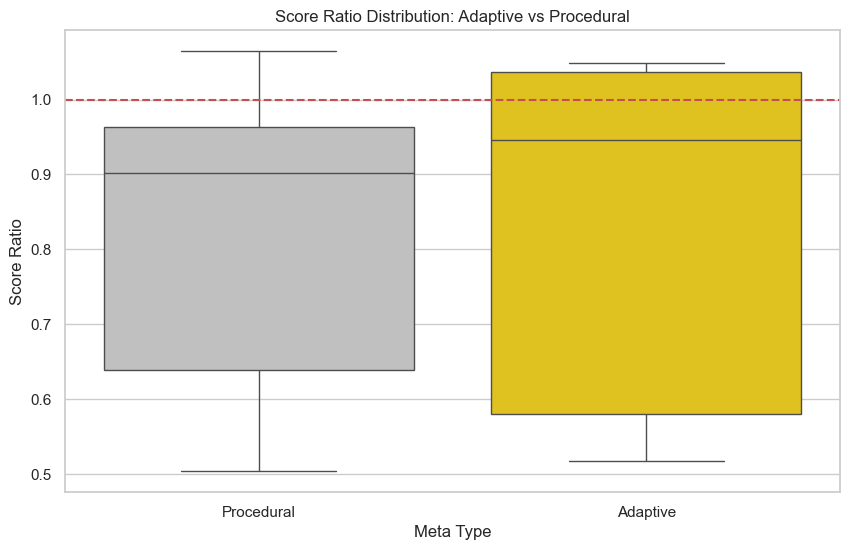

In [6]:
# Adaptive vs Procedural
# Is Adaptive better than the sum of its parts?
plt.figure(figsize=(10, 6))

comparison_df = df[
    df["Strategy Type"].str.contains("Adaptive|Passive|Thief|Troll|Turtle|Random")
].copy()
comparison_df["Meta Type"] = comparison_df["Strategy Type"].apply(
    lambda x: "Adaptive" if "Adaptive" in x else "Procedural"
)

# Custom palette for just two items doesn't need bronze, but consistent with rank
meta_pal = get_rank_palette(comparison_df, "Meta Type", "Score Ratio")

sns.boxplot(
    data=comparison_df,
    x="Meta Type",
    y="Score Ratio",
    hue="Meta Type",
    palette=meta_pal,
    legend=False,
)
plt.title("Score Ratio Distribution: Adaptive vs Procedural")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark")
plt.show()

# Detailed Adaptive View
# print(df[df["Strategy Type"] == "Adaptive"].groupby("Name")["Score Ratio"].describe())

### By dimension

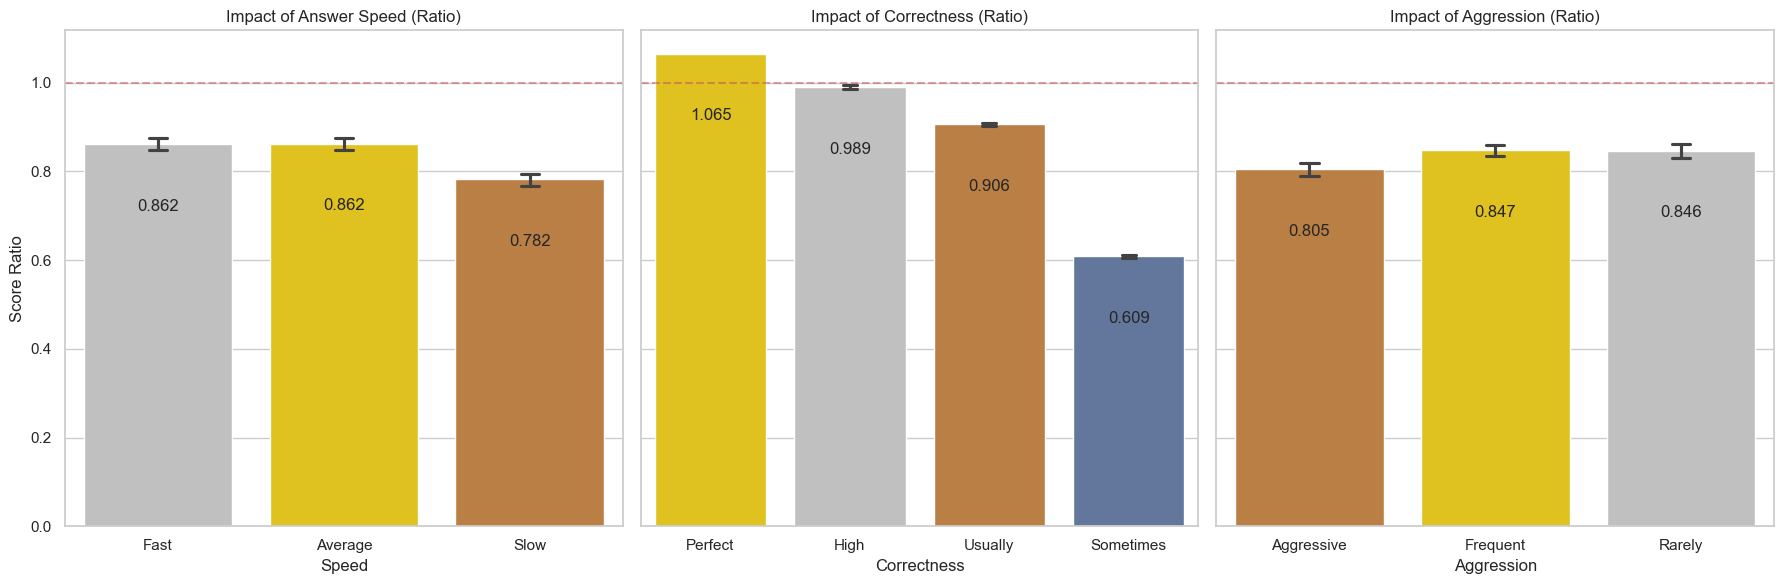

In [7]:
# Dimensional Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Remove Benchmark/NA for clean dimensional plots
# Keep only procedural (exclude Benchmark which has N/A dimensions)
dim_df = df[df["Speed"] != "N/A"]

# Order specifics
speed_order = ["Fast", "Average", "Slow"]
acc_order = ["Perfect", "High", "Usually", "Sometimes"]
# Note: "Passive" core strategy has "Rarely" aggression, but some might be "Aggressive" if defined so.
agg_order = ["Aggressive", "Frequent", "Rarely"]

# Generate palettes relative to the filtered data (dim_df)
speed_pal = get_rank_palette(dim_df, "Speed", "Score Ratio")
acc_pal = get_rank_palette(dim_df, "Correctness", "Score Ratio")
agg_pal = get_rank_palette(dim_df, "Aggression", "Score Ratio")

# Using modern seaborn API
sns.barplot(
    ax=axes[0],
    data=dim_df,
    x="Speed",
    y="Score Ratio",
    order=speed_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Speed",
    palette=speed_pal,
    legend=False,
)
axes[0].set_title("Impact of Answer Speed (Ratio)")
add_bar_labels(axes[0], fmt="%.3f")

sns.barplot(
    ax=axes[1],
    data=dim_df,
    x="Correctness",
    y="Score Ratio",
    order=acc_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Correctness",
    palette=acc_pal,
    legend=False,
)
axes[1].set_title("Impact of Correctness (Ratio)")
add_bar_labels(axes[1], fmt="%.3f")

sns.barplot(
    ax=axes[2],
    data=dim_df,
    x="Aggression",
    y="Score Ratio",
    order=agg_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Aggression",
    palette=agg_pal,
    legend=False,
)
axes[2].set_title("Impact of Aggression (Ratio)")
add_bar_labels(axes[2], fmt="%.3f")

# Add Benchmark Line to all (Ratio = 1.0)
for ax in axes:
    ax.axhline(1.0, color="r", linestyle="--", alpha=0.5, label="Benchmark")

plt.tight_layout()
plt.show()

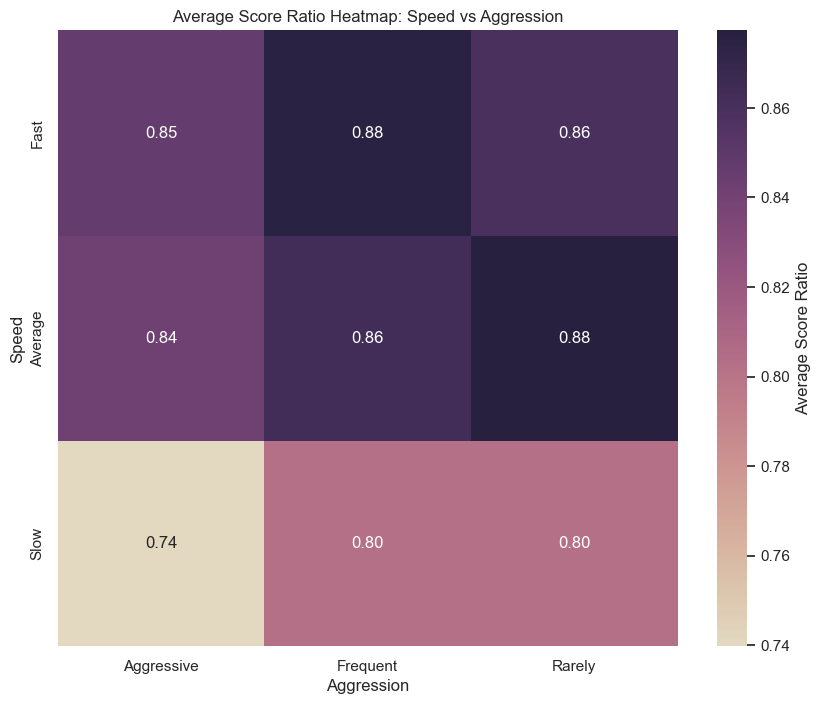

In [8]:
# Heatmap: Speed vs Aggression (Average Score Ratio)
# Filter for procedural only
proc_df = df[df["Speed"] != "N/A"]

heatmap_data_agg = proc_df.pivot_table(
    index="Speed", columns="Aggression", values="Score Ratio", aggfunc="mean"
)

# Reorder indices for better readability
speed_order = ["Fast", "Average", "Slow"]
agg_order = ["Aggressive", "Frequent", "Rarely"]
# Filter to existing
speed_order_agg = [s for s in speed_order if s in heatmap_data_agg.index]
agg_order_agg = [a for a in agg_order if a in heatmap_data_agg.columns]

heatmap_data_agg = heatmap_data_agg.reindex(
    index=speed_order_agg, columns=agg_order_agg
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data_agg,
    annot=True,
    fmt=".2f",
    # https://seaborn.pydata.org/tutorial/color_palettes.html
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    cbar_kws={"label": "Average Score Ratio"},
)
plt.title("Average Score Ratio Heatmap: Speed vs Aggression")
plt.show()

Top 15 Performing Players:
                    Name   Score  Score Ratio  Streak Core Strategy    Speed  \
20        Perfect_Player  108405     1.064647     730       Passive     Fast   
832        Thief_AHR_752  107445     1.055219       1         Thief  Average   
588       Random_AHR_508  107425     1.055022      66        Random  Average   
1055      Random_FHR_975  107325     1.054040      10        Random     Fast   
807       Random_AHR_727  107090     1.051732       7        Random  Average   
1575    Passive_FHA_1495  106985     1.050701     722       Passive     Fast   
819        Thief_AHR_739  106910     1.049964      16         Thief  Average   
633       Random_AHR_553  106870     1.049572      19        Random  Average   
742       Random_AHR_662  106835     1.049228      40        Random  Average   
890       Random_AHR_810  106835     1.049228      48        Random  Average   
29     Adaptive_Expert_9  106795     1.048835     717      Adaptive     Fast   
34    Adaptiv

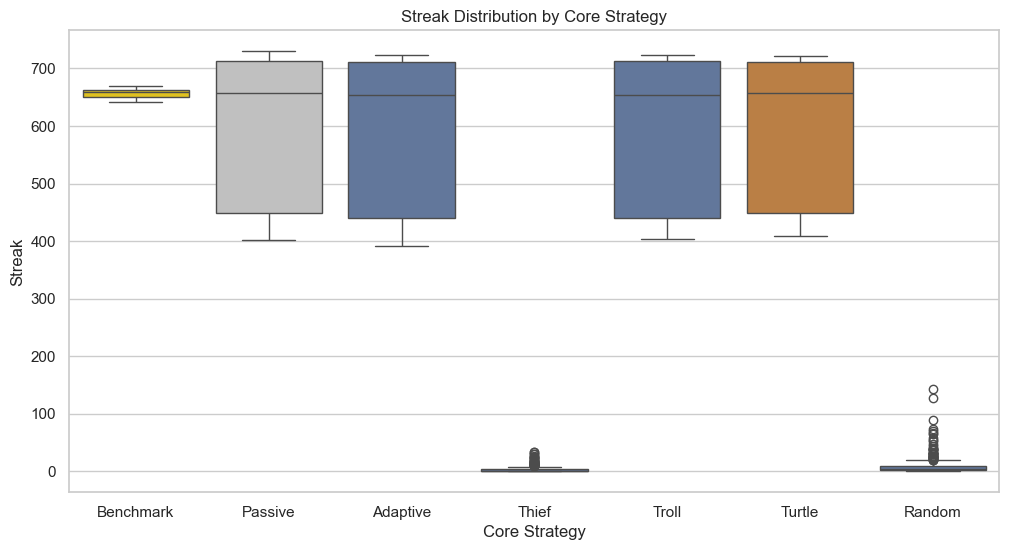

In [9]:
# Top Performers Analysis
# Group by Name/Config to see which specific combinations win most often across simulation runs (if multiple runs)
# Since we have one run with many players, we just look at the top individual players
top_performers = df.sort_values("Score", ascending=False).head(15)

print("Top 15 Performing Players:")
display_cols = [
    "Name",
    "Score",
    "Score Ratio",  # Added Ratio
    "Streak",
    "Core Strategy",
    "Speed",
    "Correctness",
    "Aggression",
]
# Only show columns that exist (e.g. if Benchmark is top)
print(top_performers[display_cols])

# Visualize Streak Distribution by Core Strategy
plt.figure(figsize=(12, 6))
streak_pal = get_rank_palette(df, "Core Strategy", "Streak")  # Rank by Streak this time
sns.boxplot(
    data=df,
    x="Core Strategy",
    y="Streak",
    hue="Core Strategy",
    palette=streak_pal,
    legend=False,
)
plt.title("Streak Distribution by Core Strategy")
plt.show()